In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.stats import norm
from scipy.stats import gamma

## Definition of the multivariate phenotype

There is in this example 5 traits.

Each trait represents a dimension of a latent space, which in fact encodes information for one specific part of the global population.

Then, a certain amount of noise is added.

In [3]:
m = 5000 # sample size
n_traits = 4 # number of dimensions
traits = [f'X{i}' for i in range(1,n_traits+1)]

# Number of subjects (different sub-population) in each trait
m1 = 2000
m2 = 500
m3 = 1000
m4 = m - m1 - m2 - m3

In [65]:
def generate_X_i(list_m, list_sigma=None, law='normal'):
    list_m = np.array(list_m)
    if list_sigma == None:
        list_sigma = [1 for i in range(len(list_m))]
    list_X = []
    if law == 'normal':
        for i in range(len(list_m)):
            X = np.concatenate(
                [np.zeros(list_m[0:i].sum()), 
                np.sort(np.random.normal(loc=0, scale=list_sigma[i], size=list_m[i])), 
                np.zeros(list_m.sum()-list_m[0:i+1].sum())]
                    )
            list_X.append(X)
    return list_X

In [66]:
list_X = generate_X_i([m1, m2, m3, m4])

# Sparse representation space
X = np.transpose(np.stack(list_X))
# Mean and Variance
print('Mean for each column:', X.mean(axis=0))
print('Variance for each column:', X.var(axis=0))
X

Mean for each column: [ 0.00930543  0.00217012  0.00435955 -0.0049789 ]
Variance for each column: [0.38861746 0.10264647 0.20273109 0.29202848]


array([[-2.99180761,  0.        ,  0.        ,  0.        ],
       [-2.84955596,  0.        ,  0.        ,  0.        ],
       [-2.76350467,  0.        ,  0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        ,  3.40786062],
       [ 0.        ,  0.        ,  0.        ,  3.78898366],
       [ 0.        ,  0.        ,  0.        ,  3.83886665]])

In [67]:
# Sparse representation space with noise
noise = True

if noise:
    for i in range(len(traits)):
        X[:,i] += np.random.randn(m)*4
print(X)

[[-5.79315043 -2.44702228 -0.08016403  0.89239515]
 [ 1.7335152  -2.26608466  2.02570643 -0.63559451]
 [-3.78156104 -0.99279962  0.45717458 -1.687557  ]
 ...
 [ 4.7669417  -2.26294099 -3.35650358 -0.9421649 ]
 [ 1.35052242 -0.75264372  2.39195059  5.12961283]
 [-1.72732412  2.62775058 -1.7079783   5.44627888]]


In [68]:
# to add a duplicate of a column
n_traits += 2
traits = [f'X{i}' for i in range(1,n_traits+1)]
X = np.hstack((X, np.tile(X[:, [-1]], 1)))
X = np.hstack((X, np.tile(X[:, [0]], 1)))
X[:,-1] += np.random.randn(m)*2
X[:,-2] += np.random.randn(m)*2

In [69]:
# Mean and Variance
print('Mean for each column:', X.mean(axis=0))
print('Variance for each column:', X.var(axis=0), '\n')

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Mean and Variance
print('Mean for each column:', X.mean(axis=0))
print('Variance for each column:', X.var(axis=0))

Mean for each column: [-0.00058545 -0.01553767 -0.06227444  0.07824666  0.04351566  0.01629845]
Variance for each column: [16.65949058 15.9969662  16.45952961 16.03532487 19.99194035 20.27688938] 

Mean for each column: [-1.42108547e-18 -2.84217094e-18 -4.26325641e-18  2.41584530e-17
  0.00000000e+00 -7.10542736e-18]
Variance for each column: [1. 1. 1. 1. 1. 1.]


## Definition of the genotype

In [70]:
genotype = np.concatenate([np.linspace(0, 2, m1), np.linspace(0, 2, m2), np.linspace(0, 2, m3), np.linspace(0, 2, m4)])
genotype = genotype.round()


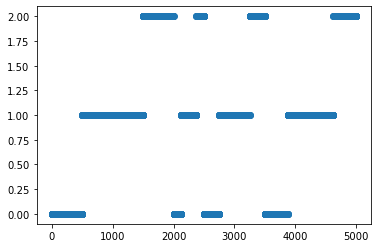

In [71]:
plt.scatter(range(0,m),genotype)

## Correlation between the different dimensions

<AxesSubplot:>

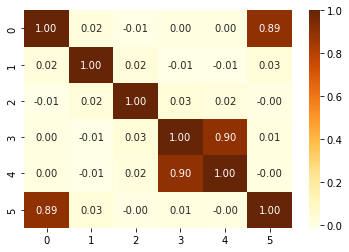

In [72]:
corr = np.corrcoef(X, rowvar=False)
sns.heatmap(corr, cmap="YlOrBr", annot=True, fmt=".2f")

## Correlation with the genotype

In [73]:
merge = pd.DataFrame(X, columns=[f'X{i}' for i in range(1,n_traits+1)])
merge['Genotype'] = genotype
merge['PermGenotype'] = np.random.permutation(genotype)
merge

,X1,X2,X3,X4,X5,X6,Genotype,PermGenotype
0,-1.419188,-0.607929,-0.004410,0.203313,0.564979,-0.684540,0.0,0.0
1,0.424858,-0.562690,0.514657,-0.178264,0.577101,0.036862,0.0,1.0
2,-0.926346,-0.244339,0.128037,-0.440964,-0.858163,-1.114341,0.0,2.0
3,-0.138119,-0.572783,-0.602383,-0.863273,-0.345354,-0.314339,0.0,1.0
4,-0.596423,0.322169,0.563623,-0.157989,-0.694926,-0.474055,0.0,1.0
...,...,...,...,...,...,...,...,...
4995,0.059995,-0.636400,2.086125,0.010024,0.251938,0.292690,2.0,1.0
4996,1.610668,0.366222,2.077666,2.053968,2.135400,1.121950,2.0,1.0
4997,1.168052,-0.561904,-0.811980,-0.254822,-0.356809,0.752270,2.0,2.0
4998,0.331024,-0.184294,0.604931,1.261450,0.764503,-0.236342,2.0,1.0


In [74]:
correlations = merge.corr()
correlations_with_genotype = correlations['Genotype'].drop(['Genotype', 'PermGenotype'])
print(correlations_with_genotype, '\n')

correlations_with_PermGenotype = correlations['PermGenotype'].drop(['PermGenotype', 'PermGenotype'])
print(correlations_with_PermGenotype)

X1    0.091496
X2    0.017595
X3    0.033782
X4    0.067448
X5    0.066386
X6    0.082524
Name: Genotype, dtype: float64 

X1          0.009540
X2         -0.013626
X3         -0.011426
X4          0.030749
X5          0.026172
X6          0.014612
Genotype    0.017200
Name: PermGenotype, dtype: float64


In [75]:
def mahalanobis_norm_perm_function(merge, traits, genotype,  nb_perm_geno = 5000):
    """
    Input:
        merge: df
        traits: list of str
        nb_perm_geno: int
    
    Output:
        list_mahalanobis_norm_perm: list of float
    """
    list_mahalanobis_norm_perm = []
    for i in range(nb_perm_geno):
        merge['PermGenotype'] = np.random.permutation(genotype)
        perm_geno = sm.add_constant(merge['PermGenotype'])
        list_z_score_perm = []

        for trait in traits:
            model_perm = sm.OLS(merge[trait], perm_geno)
            results_perm = model_perm.fit()
            list_z_score_perm.append(results_perm.tvalues.iloc[1])

        z_score_perm = np.array(list_z_score_perm)
        mahalanobis_norm_perm = (z_score_perm @ np.linalg.inv(corr)) @ z_score_perm.T

        list_mahalanobis_norm_perm.append(mahalanobis_norm_perm)
    return list_mahalanobis_norm_perm

In [76]:
nb_perm_geno = 5000
list_mahalanobis_norm_perm = mahalanobis_norm_perm_function(merge, traits, genotype, nb_perm_geno)

## Univariate regression: Genotype predicts each dimension

In [79]:
def UniVar_reg(merge, traits):
    geno = sm.add_constant(merge['Genotype'])
    list_betas_orig = []
    list_z_score_orig = []

    for trait in traits:
        model_orig = sm.OLS(merge[trait], geno)
        results_orig = model_orig.fit()

        print("Trait:", trait)
        print("Betas:", format(results_orig.params.iloc[1], '.4f'))
        print("t-values:", format(results_orig.tvalues.iloc[1], '.4f'))
        print("p-values:", results_orig.pvalues.iloc[1], '\n')

        list_betas_orig.append(results_orig.params.iloc[1])
        list_z_score_orig.append(results_orig.tvalues.iloc[1])

        #betas = results_orig.params         # Regression coefficients (β)
        #standard_errors = results_orig.bse  # Standard errors (SE)

        #z_scores = betas / standard_errors # Compute Z-scores which are the tvalues
        #print('z-score for each dimension:')
        #print(z_scores, "\n")

        #p_values = 2 * norm.sf(abs(z_scores)) # Compute p-values from Z-scores
        #print('p-value for each dimension:')
        #print(p_values)

    return list_betas_orig, list_z_score_orig

In [80]:
list_betas_orig, list_z_score_orig = UniVar_reg(merge, traits)

Trait: X1
Betas: 0.1294
t-values: 6.4957
p-values: 9.068259156022074e-11 

Trait: X2
Betas: 0.0249
t-values: 1.2441
p-values: 0.21352822416812292 

Trait: X3
Betas: 0.0478
t-values: 2.3897
p-values: 0.01690046744392659 

Trait: X4
Betas: 0.0954
t-values: 4.7792
p-values: 1.8099515586831417e-06 

Trait: X5
Betas: 0.0939
t-values: 4.7036
p-values: 2.6245281892262252e-06 

Trait: X6
Betas: 0.1167
t-values: 5.8541
p-values: 5.100933984193683e-09 



## Combinaison of the univariate results

In [81]:
def MOSTest(list_z_score_orig, corr, list_mahalanobis_norm_perm, plot_fit=False, nb_perm_geno=5000):
    z_score_orig = np.array(list_z_score_orig )

    print(z_score_orig)
    mahalanobis_norm_orig = (z_score_orig @ np.linalg.inv(corr)) @ z_score_orig.T
    print(mahalanobis_norm_orig)

    print('MOSTEST p-value')
    fit_alpha, fit_loc, fit_scale = gamma.fit(list_mahalanobis_norm_perm)
    p_value_orig = 1-gamma.cdf(mahalanobis_norm_orig, a=fit_alpha, loc=fit_loc, scale=fit_scale)
    print(p_value_orig)

    if plot_fit:
        plt.hist(gamma.rvs(a=fit_alpha, loc=fit_loc, scale=fit_scale, size=nb_perm_geno), alpha=0.32, bins=60)
        plt.hist(list_mahalanobis_norm_perm, alpha=0.5, bins=60)
        plt.show()

    return p_value_orig

[6.49569148 1.24408065 2.3896676  4.7792483  4.70363675 5.85413589]
72.54405040072099
MOSTEST p-value
1.4777068457760834e-13


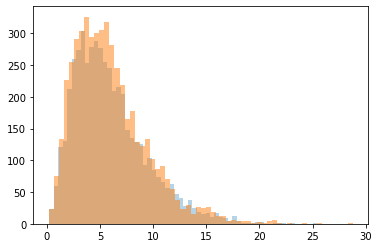

1.4777068457760834e-13

In [82]:
MOSTest(list_z_score_orig, corr, list_mahalanobis_norm_perm, plot_fit=True)

In [85]:
(np.array([6.49569148, 1.24408065, 2.3896676,  4.7792483,  ])**2).sum()

72.29347001859165

## Univariate regression: Each dimension predicts the genotype

In [86]:
list_betas = []

for trait in [f'X{i}' for i in range(1,n_traits+1)]:
    print("Trait:", trait)
    dim = sm.add_constant(merge[trait])
    model = sm.OLS(merge['Genotype'],dim)
    results = model.fit()
    print("Estimated betas:", results.params.iloc[1]) # to get the betas
    list_betas.append(results.params.iloc[1])
    print("t_values:", results.tvalues.iloc[1]) # which is in fact also the z-score
    print("P-values:", results.pvalues.iloc[1], '\n')

Trait: X1
Estimated betas: 0.06469739057371146
t_values: 6.495691479389044
P-values: 9.068259156023194e-11 

Trait: X2
Estimated betas: 0.012441369165731731
t_values: 1.244080647548695
P-values: 0.21352822416812414 

Trait: X3
Estimated betas: 0.023887814018172082
t_values: 2.389667597456626
P-values: 0.016900467443926714 

Trait: X4
Estimated betas: 0.04769318796072481
t_values: 4.779248299199262
P-values: 1.809951558683158e-06 

Trait: X5
Estimated betas: 0.04694199535976597
t_values: 4.703636750102711
P-values: 2.6245281892262744e-06 

Trait: X6
Estimated betas: 0.05835335023939775
t_values: 5.854135892089893
P-values: 5.100933984193757e-09 



In [87]:
np.array(list_betas)/list_betas[0]

array([1.        , 0.19230094, 0.36922376, 0.73717329, 0.72556242,
       0.90194287])

## Multivariate regression: set of dimension to predict the genotype (linear)

In [88]:
pheno = sm.add_constant(merge[[f'X{i}' for i in range(1,n_traits+1)]])
model = sm.OLS(merge['Genotype'], pheno)
results = model.fit()
print("Estimated betas:", '\n', results.params, '\n') # to get the betas
print("t_values:", '\n', results.tvalues, '\n') # which is in fact also the z-score
print("P-values:", '\n', results.pvalues, '\n')


Estimated betas: 
 const    1.000000
X1       0.064775
X2       0.011137
X3       0.023148
X4       0.028472
X5       0.020800
X6      -0.000100
dtype: float64 

t_values: 
 const    100.658435
X1         2.903548
X2         1.120025
X3         2.327683
X4         1.271159
X5         0.928960
X6        -0.004489
dtype: float64 

P-values: 
 const    0.000000
X1       0.003706
X2       0.262757
X3       0.019969
X4       0.203731
X5       0.352955
X6       0.996419
dtype: float64 



In [89]:
np.array(results.params[[f'X{i}' for i in range(1,n_traits+1)]].to_list())/results.params['X1']

array([ 1.        ,  0.17193514,  0.35736633,  0.43956164,  0.32111439,
       -0.00154654])

In [90]:
results.f_pvalue

1.2191368033643557e-13

## Multivariate regression: set of dimension to predict the genotype (CCA)

In [93]:
cca = CCA(n_components=1)
cca.fit(pheno, merge['Genotype'])
print(np.array(cca.coef_[1:])/cca.coef_[1]) # The coefficients of the linear model such that Y is approximated as Y = X @ coef_.T + intercept_.

[[ 1.        ]
 [ 0.17193514]
 [ 0.35736633]
 [ 0.43956164]
 [ 0.32111439]
 [-0.00154654]]


# General study

In [625]:
m = 13000 # sample size
n_traits = 8 # number of dimensions
traits = [f'X{i}' for i in range(1,n_traits+1)]

# Number of subjects (different sub-population) in each trait
dic_m = {"m1":4000, 
         "m2":500, 
         "m3":500, 
         "m4":50, 
         "m5":50, 
         "m6":2000, 
         "m7":2900, 
         "m8":3000} # m8 = m -m1 -m2 -m3 -m4 -m5 -m6 -m7

"""
# Uniform distribution of the trait for each sub-population
a = 0
b = 2

X1 = np.concatenate([np.linspace(a, b, m1), np.zeros(m-m1)])
X2 = np.concatenate([np.zeros(m1), np.linspace(a, b, m2), np.zeros(m-m2-m1)])
X3 = np.concatenate([np.zeros(m1+m2), np.linspace(a, b, m3), np.zeros(m-m3-m2-m1)])
X4 = np.concatenate([np.zeros(m1+m2+m3), np.linspace(a, b, m4), np.zeros(m-m1-m2-m3-m4)])
X5 = np.concatenate([np.zeros(m1+m2+m3+m4), np.linspace(a, b, m5), np.zeros(m-m1-m2-m3-m4-m5)])
X6 = np.concatenate([np.zeros(m1+m2+m3+m4+m5), np.linspace(a, b, m6), np.zeros(m-m1-m2-m3-m4-m5-m6)])
X7 = np.concatenate([np.zeros(m1+m2+m3+m4+m5+m6), np.linspace(a, b, m7), np.zeros(m-m1-m2-m3-m4-m5-m6-m7)])
X8 = np.concatenate([np.zeros(m1+m2+m3+m4+m5+m6+m7), np.linspace(a, b, m8), np.zeros(m-m1-m2-m3-m4-m5-m6-m7-m8)])
"""

# Generate the n_traits sparse phenotypes
list_X = generate_X_i(list(dic_m.values())) 

X = np.transpose(np.stack(list_X))

# Generate the associated genotypes (one per sub-population)
genotype = np.concatenate([np.linspace(0, 2, dic_m["m1"]), np.linspace(0, 2, dic_m["m2"]), 
                           np.linspace(0, 2, dic_m["m3"]), np.linspace(0, 2, dic_m["m4"]), 
                           np.linspace(0, 2, dic_m["m5"]), np.linspace(0, 2, dic_m["m6"]),
                           np.linspace(0, 2, dic_m["m7"]), np.linspace(0, 2, dic_m["m8"])])
genotype = genotype.round()

list_noise = np.linspace(4,5,10)
list_most_pval = []
list_multi_pval = []
dic_univ_betas = {}
dic_multiv_betas = {}
dic_cca_betas = {}
dic_fake_h2 = {}

for noise_volume in list_noise:
    fake_h2 = []
    for i in range(len(traits)):
        rand_noise = 2*np.random.rand()
        X[:,i] += np.random.randn(m)*(noise_volume + rand_noise)
        fake_h2.append(dic_m[f"m{i+1}"]/np.array(list(dic_m.values())).sum() * (noise_volume + rand_noise)**2)

    dic_fake_h2[noise_volume] = fake_h2

    corr = np.corrcoef(X, rowvar=False)
    merge = pd.DataFrame(X, columns=[f'X{i}' for i in range(1,n_traits+1)])
    merge['Genotype'] = genotype
    mahalanobis_norm_perm = mahalanobis_norm_perm_function(merge, traits, genotype)
    list_betas_orig, list_z_score_orig = UniVar_reg(merge, traits)
    dic_univ_betas[noise_volume] = np.array(list_betas_orig)/list_betas_orig[0]

    most_pval = MOSTest(list_z_score_orig, corr, list_mahalanobis_norm_perm)
    list_most_pval.append(most_pval)

    pheno = sm.add_constant(merge[[f'X{i}' for i in range(1,n_traits+1)]])
    model = sm.OLS(merge['Genotype'], pheno)
    results = model.fit()
    multi_pval = results.f_pvalue

    dic_multiv_betas[noise_volume] = np.array(results.params[[f'X{i}' for i in range(1,n_traits+1)]].to_list())/results.params['X1']
    list_multi_pval.append(multi_pval)

    cca = CCA(n_components=1)
    cca.fit(pheno, merge['Genotype'])
    dic_cca_betas[noise_volume] = np.array(cca.coef_[1:])/cca.coef_[1]

Trait: X1
Betas: 0.3974
t-values: 7.7339
p-values: 1.1191885191081772e-14 

Trait: X2
Betas: -0.0114
t-values: -0.1957
p-values: 0.8448719937084883 

Trait: X3
Betas: 0.0460
t-values: 0.7656
p-values: 0.44391664053137736 

Trait: X4
Betas: 0.0104
t-values: 0.1599
p-values: 0.8729509289797015 

Trait: X5
Betas: 0.0159
t-values: 0.2718
p-values: 0.7858121270267238 

Trait: X6
Betas: 0.2274
t-values: 3.5421
p-values: 0.000398401283571463 

Trait: X7
Betas: 0.2535
t-values: 4.9589
p-values: 7.17737800967676e-07 

Trait: X8
Betas: 0.3285
t-values: 5.6214
p-values: 1.932692275572261e-08 

[ 7.73394932 -0.1956694   0.7656195   0.15991448  0.27175838  3.54206295
  4.95893998  5.62144088]
129.65914458738584
MOSTEST p-value
0.0
Trait: X1
Betas: 0.4041
t-values: 5.5559
p-values: 2.8165433970630572e-08 

Trait: X2
Betas: 0.0209
t-values: 0.2681
p-values: 0.7886381848402066 

Trait: X3
Betas: -0.0301
t-values: -0.3152
p-values: 0.7526018997991195 

Trait: X4
Betas: 0.0205
t-values: 0.2356
p-values:

## Evolution of the estimated betas (comparison between univariate and multivariate approaches)

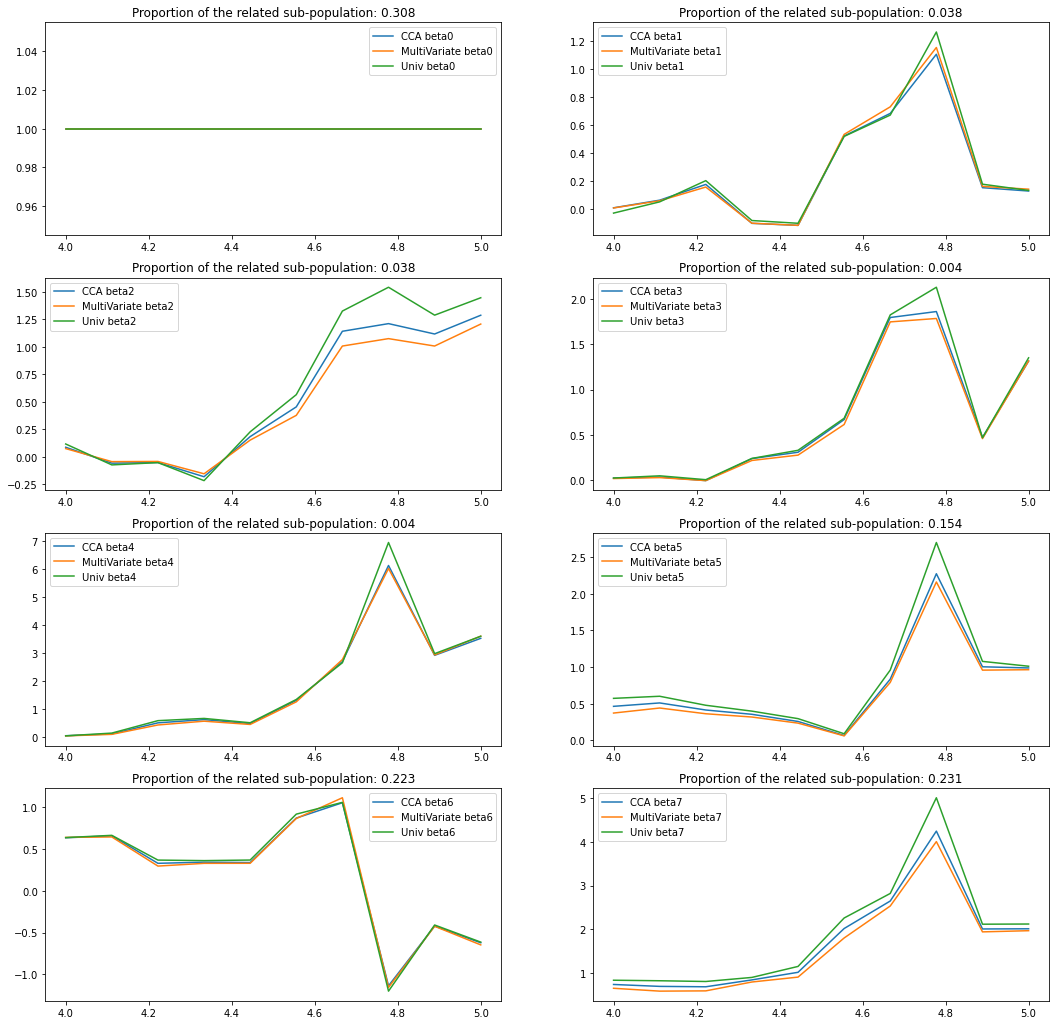

In [626]:
plt.figure(figsize=(18,18))
for i in range(len(traits)):
    plt.subplot(len(traits)//2, 2, i+1)
    plt.plot(list_noise, [dic_cca_betas[noise][i] for noise in list_noise], label=f'CCA beta{i}')
    plt.plot(list_noise, [dic_multiv_betas[noise][i] for noise in list_noise], label=f'MultiVariate beta{i}')
    plt.plot(list_noise, [dic_univ_betas[noise][i] for noise in list_noise], label=f'Univ beta{i}')
    plt.legend()
    plt.title('Proportion of the related sub-population: '+ format(dic_m[f"m{i+1}"]/np.array(list(dic_m.values())).sum(), '.3f'))
plt.show()

## Evolution of the -log10(p-value) as a function of the signal to noise ratio

/tmp/ipykernel_2104366/2559076476.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(list_noise, -np.log10(np.array(list_most_pval)), label='MOSTest')


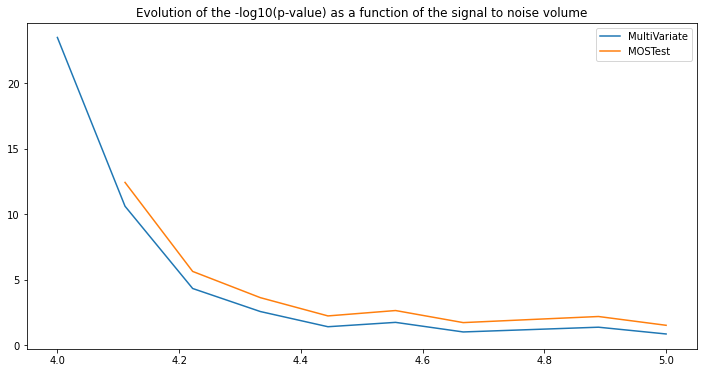

In [638]:
plt.figure(figsize=(12,6))
plt.plot(list_noise, -np.log10(np.array(list_multi_pval)), label='MultiVariate')
plt.plot(list_noise, -np.log10(np.array(list_most_pval)), label='MOSTest')
plt.title('Evolution of the -log10(p-value) as a function of the signal to noise volume')
plt.legend()
plt.show()

In [661]:
print(format(list_multi_pval[-1], '.2'))
print(format(list_most_pval[-1], '.2'))

0.14
0.031
